# Project 2: Binary Classification with Image Data Set

<span style='color:#f44336'>300 Points</span>

<span style='color:#f44336'><u>Due Date</u></span><span style='color:#f44336'>: </span>  
<span style='color:#f44336'>19 March 2026 midnight </span>

<span style='color:#f44336'>Submit a **pdf in Canvas** and **share your notebook** with your instructor (with edit access). </span>

---

## Documentation Guidance

Complete each task to the best of your ability. You may use generative AI tools (e.g., CoPilot, Perplexity, Gemini, ChatGPT) to generate code and assist with drafting or editing written responses, provided their use is documented per the DAAW.


If you use generative AI, you **must** include the following **in-text acknowledgement** (as comments in the relevant code or markdown cell):

1. Describe how the material was generated, including prompts used.  
2. Summarize the output (preferably with a link to the conversation).  
3. Explain how you modified the output.

---

## Assignment Overview

In this problem set, you will work with the **Fashion-MNIST** dataset, a standard benchmark dataset for image classification. Fashion-MNIST consists of 28×28 grayscale images of clothing items, each belonging to one of 10 categories.

For this assignment, you will focus on a **binary classification task** using a subset of the dataset:

- **Class 0:** Sneaker  
- **Class 1:** Ankle Boot  

The dataset is loaded and preprocessed using the **starter code provided in the next code cell**, which:
- Loads the Fashion-MNIST dataset
- Filters the data to include only Sneakers and Ankle Boots
- Converts labels to a binary format
- Displays example images from the dataset

You should **run and inspect that code before proceeding**.

---

## Objective

Your objective is to **develop and assess two different binary classifiers (choose one linear model and one non-linear or distance-based model)** that predict whether an image represents a **Sneaker or an Ankle Boot**.

Use Chapters 2 and 3 of Géron as a guide.

---

## Requirements (for EACH classifier)

You must complete the following for **each** classifier (ensure you go through the proper preprocessing steps required for your model and also use CV on the training set to help with hyperparameter tuning):

- **Confusion Matrix:** Provide a confusion matrix **on the held out test set** accompanied by an explanation of the True Positives, True Negatives, False Positives, and False Negatives for better insights into the classifier's behavior.

- **Cross-Validated Performance Metrics:** Calculate performance measures \(precision, recall, and $F_1$ score\) through cross\-validation.

- **Precision–Recall Curve:** Plot the Precision\-Recall curve for your classifier \(properly labeled\).

- **ROC Curve:** Plot an ROC curve for your classifier \(properly labeled\).

- **Sensitivity to Standardization:** Standardize the pixel values and compare model performance before and after scaling.



---

## Written Analysis

In a text cell at the end of this notebook, write 2 paragraphs **summarizing** and **comparing** your classifiers and assessing their effectiveness. As part of your summary, provide a clear interpretation of the performance measures \(precision, recall, and $F_1$ score\) and ROC curve. Your response should reflect a thoughtful analysis of each of the classifier's strengths and limitations in the given context, using specific examples or results from your data to support your conclusions. What hyperparameters did you end up tuning for each of your models and what values provided the best results? Why do you think one model outperforms the other? Which classifier is most sensitive to standardization, and why?

---

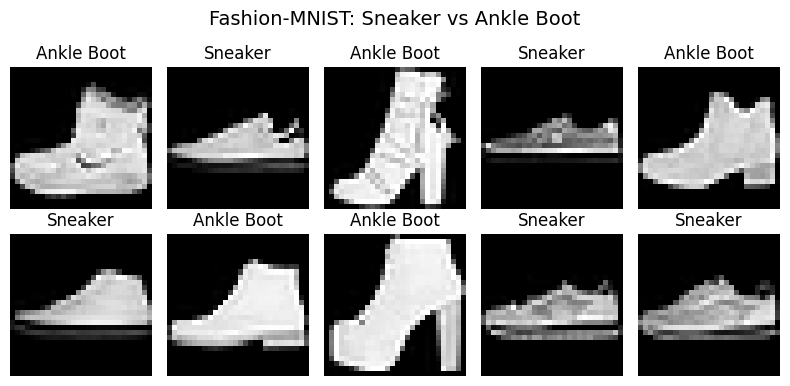

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

# Load dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Keep only sneaker (7) and ankle boot (9)
mask_train = np.isin(y_train, [7, 9])
mask_test  = np.isin(y_test,  [7, 9])

X_train_bin = X_train[mask_train]
y_train_bin = y_train[mask_train]

X_test_bin = X_test[mask_test]
y_test_bin = y_test[mask_test]

# Map labels: sneaker -> 0, ankle boot -> 1
label_map = {7: 0, 9: 1}
y_train_bin = np.vectorize(label_map.get)(y_train_bin)
y_test_bin  = np.vectorize(label_map.get)(y_test_bin)

# Class names for plotting
class_names = ["Sneaker", "Ankle Boot"]

# Display sample images
plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_bin[i], cmap="gray")
    plt.title(class_names[y_train_bin[i]])
    plt.axis("off")

plt.suptitle("Fashion-MNIST: Sneaker vs Ankle Boot", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
print("X_train_bin shape:", X_train_bin.shape)
print("y_train_bin shape:", y_train_bin.shape)


X_train_bin shape: (12000, 28, 28)
y_train_bin shape: (12000,)


In [6]:
print("X_test_bin shape:", X_test_bin.shape)
print("y_test_bin shape:", y_test_bin.shape)


X_test_bin shape: (2000, 28, 28)
y_test_bin shape: (2000,)


Reshaping data to fit needed dimensions (2D Array)

In [3]:
X_train_bin = X_train_bin.reshape(12000, 784)
X_test_bin = X_test_bin.reshape(2000, 784)
print("X_train_bin shape:", X_train_bin.shape)
print("X_test_bin shape:", X_test_bin.shape)

X_train_bin shape: (12000, 784)
X_test_bin shape: (2000, 784)


Using a grid search to find the best hyperparameters for both models

In [58]:
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_predict, GridSearchCV
from sklearn.metrics import precision_score, recall_score, confusion_matrix, f1_score, precision_recall_curve, roc_curve
from sklearn.preprocessing import StandardScaler

classifier = SGDClassifier()
grid = GridSearchCV(classifier,{'penalty':['l2', 'l1', 'elasticnet', None]}, cv=3)
grid.fit(X_train_bin, y_train_bin)
print('Best SGD Parameter: ' + str(grid.best_params_))

classifier = KNeighborsClassifier()
grid = GridSearchCV(classifier,{'n_neighbors':[2, 5, 10, 50, 100, 300], 'weights':['uniform', 'distance']}, cv=3)
grid.fit(X_train_bin, y_train_bin)
print('Best KNN Parameters: ' + str(grid.best_params_))

Best SGD Parameter: {'penalty': 'elasticnet'}
Best KNN Parameters: {'n_neighbors': 10, 'weights': 'uniform'}


Fitting and evaluating each of the 4 models (Stochastic Gradient Descent and K-Nearest Neighbors, each standardized and unstandardized)

Nonstandardized
Stochastic Gradient Descent
Training Data Confusion Matrix:
[[5629  371]
 [ 228 5772]]
Training Data Precision Score: 0.9396060556731238
Training Data Recall Score: 0.962
Training Data F1 Score: 0.9506711685744874
Test Data Confusion Matrix:
[[926  74]
 [ 23 977]]
Test Data Precision Score: 0.9295908658420552
Test Data Recall Score: 0.977
Test Data F1 Score: 0.9527059970745978


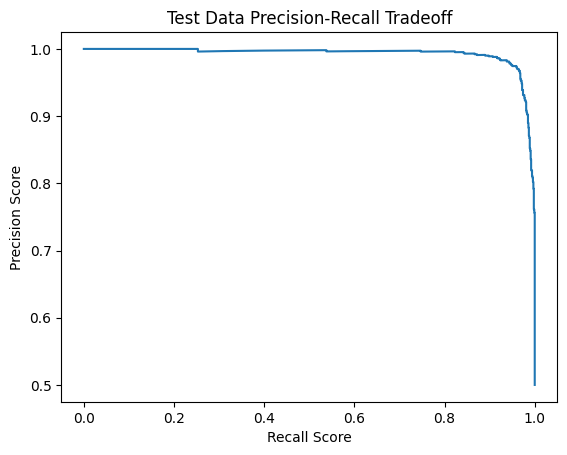

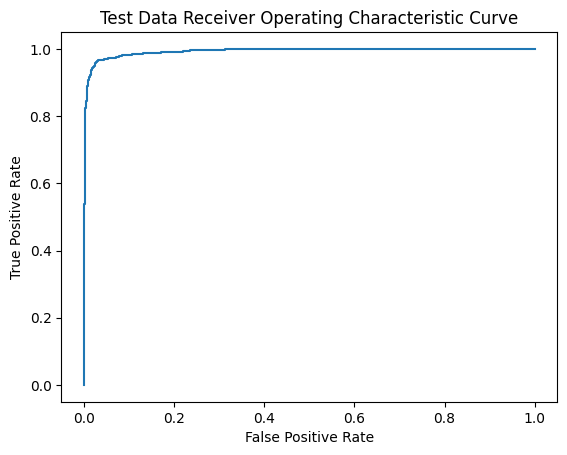

Standardized
Stochastic Gradient Descent
Training Data Confusion Matrix:
[[5711  289]
 [ 271 5729]]
Training Data Precision Score: 0.9519774011299436
Training Data Recall Score: 0.9548333333333333
Training Data F1 Score: 0.9534032284905974
Test Data Confusion Matrix:
[[956  44]
 [ 32 968]]
Test Data Precision Score: 0.9565217391304348
Test Data Recall Score: 0.968
Test Data F1 Score: 0.9622266401590457


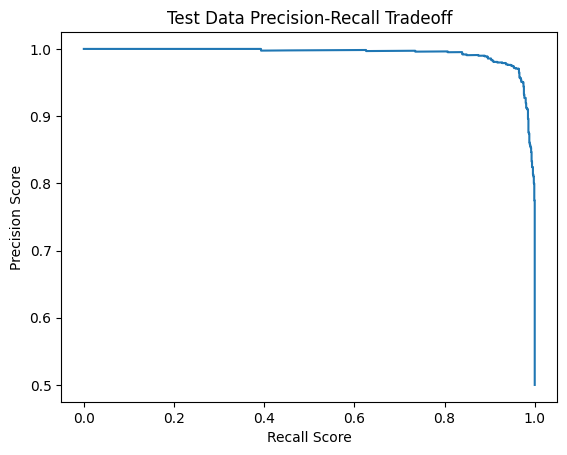

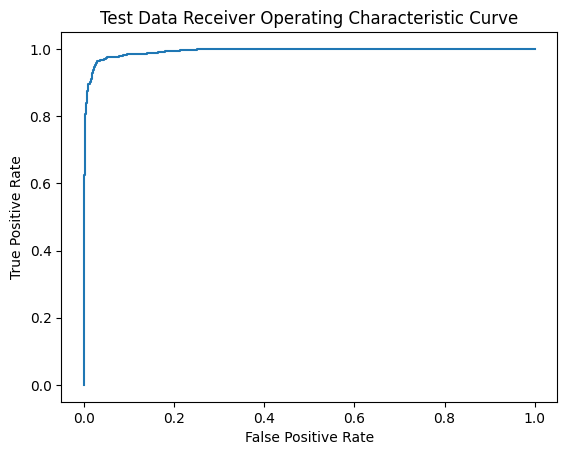

Nonstandardized
K-Nearest Neighbors
Training Data Confusion Matrix:
[[5733  267]
 [ 211 5789]]
Training Data Precision Score: 0.9559114927344782
Training Data Recall Score: 0.9648333333333333
Training Data F1 Score: 0.9603516921035169
Test Data Confusion Matrix:
[[971  29]
 [ 34 966]]
Test Data Precision Score: 0.9708542713567839
Test Data Recall Score: 0.966
Test Data F1 Score: 0.968421052631579


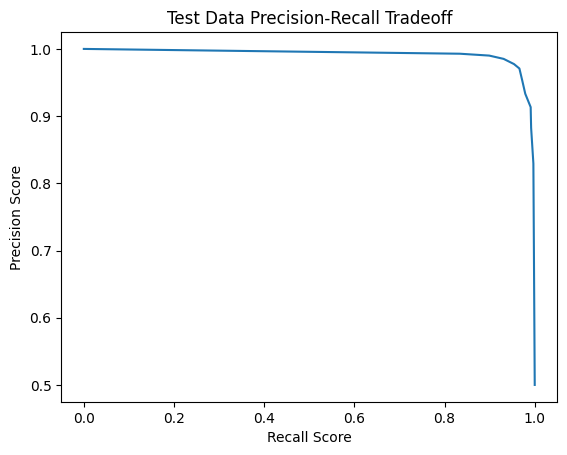

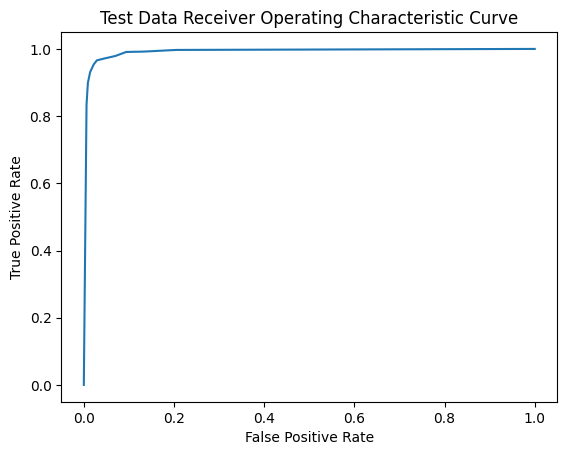

Standardized
K-Nearest Neighbors
Training Data Confusion Matrix:
[[5693  307]
 [ 207 5793]]
Training Data Precision Score: 0.949672131147541
Training Data Recall Score: 0.9655
Training Data F1 Score: 0.9575206611570248
Test Data Confusion Matrix:
[[952  48]
 [ 38 962]]
Test Data Precision Score: 0.9524752475247524
Test Data Recall Score: 0.962
Test Data F1 Score: 0.9572139303482587


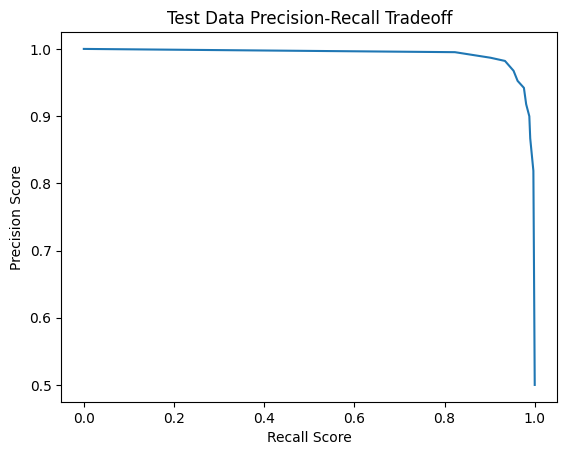

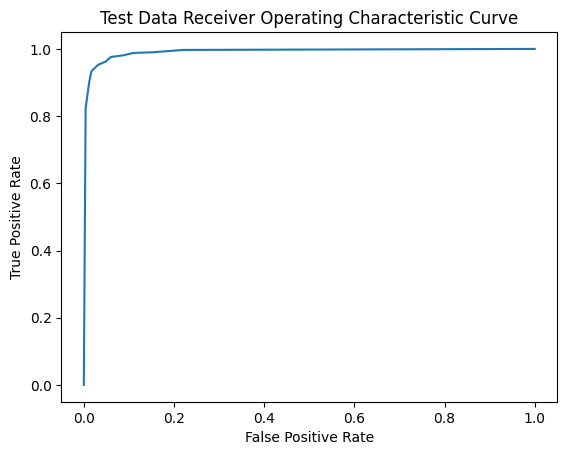

In [67]:
for i in range(4):
  if i == 1 or i == 3:
    print('Standardized')
    scaler = StandardScaler()
    X_train_bin = scaler.fit_transform(X_train_bin)
    X_test_bin = scaler.fit_transform(X_test_bin)
  else:
    print('Nonstandardized')
    X_train_bin = X_train[mask_train]
    X_test_bin = X_test[mask_test]
    X_train_bin = X_train_bin.reshape(12000, 784)
    X_test_bin = X_test_bin.reshape(2000, 784)
  if i == 0 or i == 1:
    print('Stochastic Gradient Descent')
    classifier = SGDClassifier(loss='log_loss',penalty='elasticnet')
    classifier.fit(X_train_bin, y_train_bin)
    train_guesses = cross_val_predict(classifier, X_train_bin, y_train_bin, cv=4)
    train_scores = cross_val_predict(classifier, X_train_bin, y_train_bin, cv=4, method="decision_function")
    test_guesses = classifier.predict(X_test_bin)
    test_scores = classifier.decision_function(X_test_bin)
  else:
    print('K-Nearest Neighbors')
    classifier = KNeighborsClassifier(n_neighbors=10)
    classifier.fit(X_train_bin, y_train_bin)
    train_guesses = cross_val_predict(classifier, X_train_bin, y_train_bin, cv=4)
    train_scores = cross_val_predict(classifier, X_train_bin, y_train_bin, cv=4, method="predict_proba")
    test_guesses = classifier.predict(X_test_bin)
    test_scores = classifier.predict_proba(X_test_bin)[:,1]

  print('Training Data Confusion Matrix:\n' + str(confusion_matrix(y_train_bin, train_guesses)))
  print('Training Data Precision Score: ' + str(precision_score(y_train_bin, train_guesses)))
  print('Training Data Recall Score: ' + str(recall_score(y_train_bin, train_guesses)))
  print('Training Data F1 Score: ' + str(f1_score(y_train_bin, train_guesses)))

  print('Test Data Confusion Matrix:\n' + str(confusion_matrix(y_test_bin, test_guesses)))
  print('Test Data Precision Score: ' + str(precision_score(y_test_bin, test_guesses)))
  print('Test Data Recall Score: ' + str(recall_score(y_test_bin, test_guesses)))
  print('Test Data F1 Score: ' + str(f1_score(y_test_bin, test_guesses)))

  precisions, recalls, thresholds = precision_recall_curve(y_test_bin, test_scores)
  plt.plot(recalls, precisions)
  plt.xlabel('Recall Score')
  plt.ylabel('Precision Score')
  plt.title('Test Data Precision-Recall Tradeoff')
  plt.show()

  fpr, tpr, thresholds = roc_curve(y_test_bin, test_scores)
  plt.plot(fpr, tpr)
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Test Data Receiver Operating Characteristic Curve')
  plt.show()

Overall, both classifiers perform roughly equally in categorizing the data, with each classifier hovering around 95% accuracy. Of the models created, the unstandardized K-Nearest Neighbors model with K=10 slightly outperformed the rest, with an test set F1 score of 0.968 (compared with 0.953, 0.962, and 0.957 for the other three models). Most of the models had similar precision and recall scores, though the unstandardized Stochastic Gradient Descent classifier was noticably stronger in recall than precision (0.977 versus 0.93). Given that an ankle boot corresponds to a positive observation (1-class) and a sneaker corresponds to a negative observation (0-class), this means that the proportion of actual ankle boots that were correctly predicted (recall) is higher than the proportion of ankle boot predictions that were correct (precision). Put simply, the unstandardized SGD classifier was more likely to misclassify a sneaker as an ankle boot than to misclassify an ankle boot as a sneaker. With this, its F1 score (the harmonic mean of the precision and recall) was the lowest of the 4 (0.953) because F1 score favors closeness in precision and recall.

When building the SGD classifier, I first considered tuning the loss and penalty hyperparameters, though because I was trying to utilize a logistic regression design, I set the loss hyperparameter to log loss. By then using a grid search, I determined the best setting for penalty was the "elasticnet" setting, which incorporates both a ridge and lasso regularization. This double layer of feature reduction makes sense, because the visual images show that there is a fair amount of useless data (ex. the black corners of each image) that can be suppressed. For the KNN classifier, a grid search of different numbers of neighbors reveals that the model performs best when considering 10 neighbors, but not considering the distance to each neighbor. Because KNN deals with a semi-physical space (albeit 784-dimensional space), standardizing the data changes neighbor relationships and actually decreases performance, whereas standardizing the data for the SGD classifier removes some amount of favorability for recall over precision, leading to model improvement (precision increases from 0.93 to 0.956, while recall only drops from 0.977 to 0.968). It is important to note that a weakness of SGD is that its stochastic nature makes it hard to generate repeatable results (if for some reason data must be reclassified many times) compared to KNN, but the continuous probability score (compared to the 10 discrete probability scores with 10-Nearest Neighbors) makes it easier to adjust the threshold to fine-tune the desired precison-recall ratio for a given dataset. Overall, the KNN classifier performs better because of less bias toward recall in the precision-recall tradeoff, though it does not perform significantly better and both classifiers are well-suited for the task.